# Random Forest Classification from Scratch

## Objectives
- Understand how Random Forest works.
- Implement Random Forest using NumPy.
- Use bootstrap sampling and random feature selection.
- Combine predictions using majority voting.
- Compare the implementation with Scikit-Learn.

## Random Forest Intuition

Random Forest is an ensemble learning algorithm that combines multiple
Decision Trees.

Main steps:
1. Create bootstrap samples from the training data.
2. Train a Decision Tree on each sample.
3. Randomly select features during tree construction.
4. Combine predictions using majority voting.

Random Forest generally reduces overfitting compared to a single Decision Tree.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

In [2]:
X, y = make_classification(
    n_samples=400,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    class_sep=1.4,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 320
Testing samples: 80


In [4]:
class RandomTree:
    def __init__(self, max_depth=5, max_features=None, random_state=None):
        self.max_depth = max_depth
        self.max_features = max_features
        self.rng = np.random.default_rng(random_state)
        self.root = None

    class Node:
        def __init__(
            self,
            feature=None,
            threshold=None,
            left=None,
            right=None,
            value=None
        ):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

        def is_leaf(self):
            return self.value is not None

    def fit(self, X, y):
        self.n_features = X.shape[1]

        if self.max_features is None:
            self.max_features = max(1, int(np.sqrt(self.n_features)))

        self.root = self._grow_tree(X, y, depth=0)
        return self

    def _gini(self, y):
        if len(y) == 0:
            return 0

        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)

        return 1 - np.sum(probabilities ** 2)

    def _best_split(self, X, y):
        best_gain = -np.inf
        best_feature = None
        best_threshold = None

        features = self.rng.choice(
            self.n_features,
            size=min(self.max_features, self.n_features),
            replace=False
        )

        parent_gini = self._gini(y)

        for feature in features:
            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                if not left_mask.any() or not right_mask.any():
                    continue

                n = len(y)
                n_left = left_mask.sum()
                n_right = right_mask.sum()

                child_gini = (
                    (n_left / n) * self._gini(y[left_mask])
                    + (n_right / n) * self._gini(y[right_mask])
                )

                gain = parent_gini - child_gini

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _grow_tree(self, X, y, depth):
        if (
            depth >= self.max_depth
            or len(np.unique(y)) == 1
            or len(y) < 2
        ):
            return self.Node(value=Counter(y).most_common(1)[0][0])

        feature, threshold = self._best_split(X, y)

        if feature is None:
            return self.Node(value=Counter(y).most_common(1)[0][0])

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left = self._grow_tree(
            X[left_mask],
            y[left_mask],
            depth + 1
        )

        right = self._grow_tree(
            X[right_mask],
            y[right_mask],
            depth + 1
        )

        return self.Node(
            feature=feature,
            threshold=threshold,
            left=left,
            right=right
        )

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)

        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([
            self._predict_one(x, self.root)
            for x in X
        ])

In [5]:
class RandomForestScratch:
    def __init__(
        self,
        n_trees=10,
        max_depth=5,
        max_features=None,
        random_state=42
    ):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        rng = np.random.default_rng(self.random_state)
        self.trees = []

        for _ in range(self.n_trees):
            indices = rng.choice(
                len(X),
                size=len(X),
                replace=True
            )

            X_bootstrap = X[indices]
            y_bootstrap = y[indices]

            tree = RandomTree(
                max_depth=self.max_depth,
                max_features=self.max_features,
                random_state=int(rng.integers(0, 1_000_000))
            )

            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)

        return self

    def predict(self, X):
        tree_predictions = np.array([
            tree.predict(X)
            for tree in self.trees
        ])

        final_predictions = []

        for sample_predictions in tree_predictions.T:
            final_predictions.append(
                Counter(sample_predictions).most_common(1)[0][0]
            )

        return np.array(final_predictions)

In [6]:
forest = RandomForestScratch(
    n_trees=10,
    max_depth=5,
    max_features=2,
    random_state=42
)

forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)

print("First 10 predictions:", y_pred[:10])
print("Actual values:", y_test[:10])

First 10 predictions: [0 1 1 0 0 0 0 0 0 1]
Actual values: [0 1 1 0 0 0 0 0 0 1]


In [7]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ]
})

results

,Metric,Score
0,Accuracy,0.950000
1,Precision,0.909091
2,Recall,1.000000
3,F1-Score,0.952381


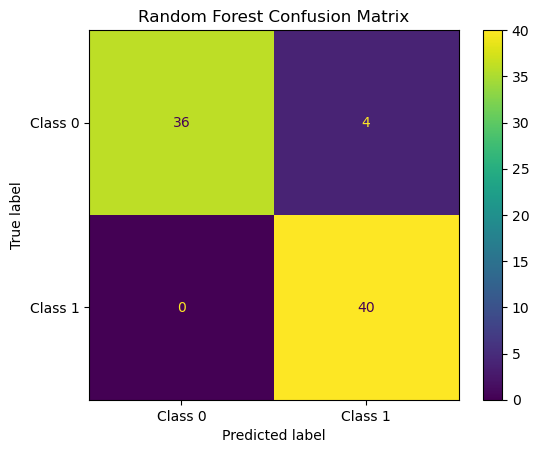

In [8]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

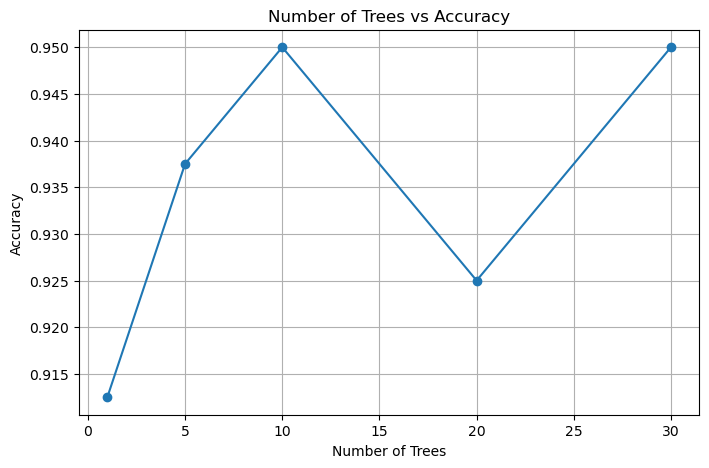

In [9]:
tree_counts = [1, 5, 10, 20, 30]
accuracies = []

for n_trees in tree_counts:
    model = RandomForestScratch(
        n_trees=n_trees,
        max_depth=5,
        max_features=2,
        random_state=42
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, predictions)
    )

plt.figure(figsize=(8, 5))

plt.plot(
    tree_counts,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Number of Trees vs Accuracy")
plt.grid(True)
plt.show()

In [10]:
sklearn_forest = RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    max_features=2,
    random_state=42
)

sklearn_forest.fit(X_train, y_train)

sklearn_pred = sklearn_forest.predict(X_test)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "From Scratch": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ],
    "Scikit-Learn": [
        accuracy_score(y_test, sklearn_pred),
        precision_score(y_test, sklearn_pred, zero_division=0),
        recall_score(y_test, sklearn_pred, zero_division=0),
        f1_score(y_test, sklearn_pred, zero_division=0)
    ]
})

comparison

,Metric,From Scratch,Scikit-Learn
0,Accuracy,0.950000,0.975000
1,Precision,0.909091,0.952381
2,Recall,1.000000,1.000000
3,F1-Score,0.952381,0.975610


## Conclusion

- Random Forest combines multiple Decision Trees.
- Bootstrap sampling creates diverse training datasets.
- Random feature selection increases tree diversity.
- Majority voting combines the predictions.
- Random Forest generally provides more stable predictions than a single tree.
- The implementation is educational and slower than optimized libraries.

## Limitations

- Training is computationally expensive because multiple trees are created.
- The implementation does not include out-of-bag evaluation.
- The implementation does not include pruning or advanced split optimization.
- Scikit-Learn is recommended for production applications.